In [3]:

!git clone https://github.com/MohamedElsayed75/FRW1NB1.git
%cd FRW1NB1/work/notebooks

Cloning into 'FRW1NB1'...
remote: Enumerating objects: 149, done.
remote: Counting objects: 100% (149/149), done.
remote: Compressing objects: 100% (120/120), done.
remote: Total 149 (delta 59), reused 79 (delta 13), pack-reused 0 (from 0)
Receiving objects: 100% (149/149), 1.91 MiB | 14.16 MiB/s, done.
Resolving deltas: 100% (59/59), done.
/content/FRW1NB1/work/notebooks


# Capstone — mirrors your deployed research paper

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

**Lane:** Refresh / Content Opportunity Scoring

**Research question:** Which content items should a client's editorial team review first for a possible refresh, based on observable search and engagement signals?

**Unit of analysis:** One client–content pair (one page, on one client's site) in the March-2026 development window.

**Decision this supports:** Out of a large content inventory, which pages go to the top of a limited manual-review queue.

**Who acts on it:** A client's content/SEO team — the queue is a starting point for human review, not an automatic content change.

**Output:** A ranked list, one row per content item, with a score, a reason code, and a recommended action (`REVIEW_REFRESH`, `REVIEW`, `MONITOR`, `NO_ACTION`).

**Cost of a wrong call:**
- False positive — an editor spends time reviewing a page that didn't need it.
- False negative — a page that's genuinely losing search traffic gets skipped, and the loss compounds before anyone notices.

**Why this needs ranking, not just a report:** In the March-2026 development slice, 9.97% of client–content pairs show a month-over-month decline in average GSC clicks. That's small enough that reviewing everything isn't necessary, but too large to review by hand without prioritization.

In [8]:
# Verified counts carried over from w05_model.ipynb (is_declining_label value_counts,
# March-2026 development slice). Not re-queried here to avoid re-hitting the
# 79M-row warehouse for a single already-computed number — see w05_model.ipynb
# for the live DuckDB/HuggingFace query.
total_pairs = 349_411
declining_pairs = 34_837
not_declining_pairs = 314_574

decline_rate = declining_pairs / total_pairs

print(f"Client-content pairs in the March-2026 development slice: {total_pairs:,}")
print(f"Pairs with a Feb->Mar GSC-click decline: {declining_pairs:,} ({decline_rate:.2%})")
print(f"Base rate to keep in mind for every metric later in this notebook: {decline_rate:.2%} positive class.")

Client-content pairs in the March-2026 development slice: 349,411
Pairs with a Feb->Mar GSC-click decline: 34,837 (9.97%)
Base rate to keep in mind for every metric later in this notebook: 9.97% positive class.


## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

**Release:** FlyRank internship warehouse (`hf://datasets/FlyRank/internship-warehouse`).

**Table:** `fact_content_daily_performance` — one row per content item, per client, per reporting date. Grain verified in W03: zero duplicate (client, content, date) combinations in the March-2026 slice.

**Date windows:** February and March 2026, used to build month-over-month features and the decline label. March 2026 raw slice = 9,841,378 rows. Aggregated to one row per client–content pair with both months present, the development set is 349,411 pairs.

**Data coverage:** Of the 9,841,378 March rows, only 3,611,061 have GSC data marked available and only 413,966 have GA4 data marked available. Analytics-based features are not equally informative for every content item as a result.

**Features used (5):** `gsc_impressions`, `gsc_clicks`, `gsc_avg_position`, `ga4_pageviews`, `ga4_sessions` — monthly averages per client–content pair.

**Deliberately excluded, and why:**
- `client_hash_id` / `content_hash_id` — used only to group rows, never as model inputs (identifiers would let a model memorize entities instead of learning a signal).
- The decline label itself, and any post-March data — kept out of the feature set to avoid target leakage (see Methodology for a caveat on this).
- Any client-identifying detail — only hashed IDs are used anywhere in this work; no client names, domains, URLs, or raw warehouse exports appear in this repo or this paper.

In [1]:
# Verified figures carried over from w03_data_contract.ipynb (grain check, row counts,
# availability check). Not re-queried here — see w03_data_contract.ipynb for the live
# DuckDB/HuggingFace queries.
march_raw_rows = 9_841_378
gsc_available_rows = 3_611_061
ga4_available_rows = 413_966
dev_pairs = 349_411

print(f"March-2026 raw rows: {march_raw_rows:,}")
print(f"Rows with GSC data available: {gsc_available_rows:,} ({gsc_available_rows/march_raw_rows:.1%})")
print(f"Rows with GA4 data available: {ga4_available_rows:,} ({ga4_available_rows/march_raw_rows:.1%})")
print(f"Client-content pairs with both Feb and Mar 2026 present: {dev_pairs:,}")

March-2026 raw rows: 9,841,378
Rows with GSC data available: 3,611,061 (36.7%)
Rows with GA4 data available: 413,966 (4.2%)
Client-content pairs with both Feb and Mar 2026 present: 349,411


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

**Baseline (Week 4):** a transparent rule, not a model. Two signals, each worth up to 40 points: month-over-month GSC click decline and month-over-month GSC impression decline (full 40 if the drop is ≤ -20%, half credit for a milder drop). A 20-point visibility floor is added if the page still has ≥100 March impressions. Total score 0–100 maps to an action: `REFRESH_NOW`/`REVIEW_REFRESH` (≥60–80 depending on notebook), `REVIEW`, `MONITOR`, `NO_ACTION`.

**Label:** `is_declining_label = 1` if a pair's average March GSC clicks are lower than its average February GSC clicks, else 0. Base rate: 9.97% (Section 1).

**Model (Week 5):** Logistic Regression, chosen because the target is binary and the model outputs an interpretable probability rather than a black-box score — a fair first comparison against a hand-written rule. Pipeline: median imputation → standardization → logistic regression (`max_iter=1000`, `random_state=42`). Five features, all measured in March only: `avg_gsc_impressions`, `avg_gsc_clicks`, `avg_position`, `avg_ga4_pageviews`, `avg_ga4_sessions`.

**Validation design:** two splits, deliberately compared. (1) Random 70/30 stratified split (Week 5) — the initial development read, but content from the same client can land in both train and test, so it doesn't test generalization to unseen clients. (2) Grouped-by-client split via `GroupShuffleSplit` (Week 6) — zero client overlap between train and test, a stricter and more honest measure of performance on clients the model has never seen. Both splits use `random_state=42`.

**Leakage checks — two separate findings, not one:**
1. *Week 3, deliberate demonstration:* a feature that directly copies the label was added on purpose. ROC-AUC went to a perfect 1.0000; removing it dropped ROC-AUC to 0.8061. This confirmed the leak-detection method works before it was needed on real features.
2. *Week 6, real finding on the actual feature set:* `avg_gsc_clicks_2026-03` — one of the five model features — is not independent of the label. The label is defined as `March clicks < February clicks`, so March clicks are *part of the target's own definition*, not just correlated with it. This means the Week-5/6 model is not a clean past→future forecast; it is a same-window association measurement. Both the 0.8259 (random) and 0.8174 (grouped) ROC-AUC figures should be read as development measurements, not evidence of forecasting ability.
3. *This week, a related finding in the baseline itself:* the baseline's `click_change_pct` signal is built from the same March clicks used in the label, so any row scoring ≥80 satisfies the label by construction (see Section 4's Precision@50 caveat). The baseline's near-perfect precision numbers are inflated by the same underlying issue as (2), just expressed through hand-written rule logic instead of a learned coefficient.

None of this invalidates the comparison between model and baseline — both are evaluated on the exact same test rows with the exact same metric — but it does mean neither number should be read as "this system predicts future decline." Both are decision-support rankings on same-window signals.

In [4]:
# Feature-by-feature leakage audit, reproduced from w06_validation_audit.ipynb (cell 22),
# plus the baseline-side finding from this week's Precision@50 addendum.
import pandas as pd

leakage_audit = pd.DataFrame({
    "feature": [
        "avg_gsc_impressions_2026-03",
        "avg_gsc_clicks_2026-03",
        "avg_position_2026-03",
        "avg_ga4_pageviews_2026-03",
        "avg_ga4_sessions_2026-03",
    ],
    "concern": [
        "Same window as the target, but not part of its definition.",
        "Directly used in the target definition (March clicks < February clicks). FLAGGED.",
        "Measured in the target window.",
        "Measured in the target window.",
        "Measured in the target window.",
    ],
})

print("Model feature audit (Week 6):")
display(leakage_audit)

print("\nBaseline-side finding (this week):")
print("click_change_pct is derived from the same March clicks used in the label.")
print("Any row with score >= 80 satisfies the label by construction, independent of ranking quality.")

Model feature audit (Week 6):


,feature,concern
0,avg_gsc_impressions_2026-03,"Same window as the target, but not part of its..."
1,avg_gsc_clicks_2026-03,Directly used in the target definition (March ...
2,avg_position_2026-03,Measured in the target window.
3,avg_ga4_pageviews_2026-03,Measured in the target window.
4,avg_ga4_sessions_2026-03,Measured in the target window.



Baseline-side finding (this week):
click_change_pct is derived from the same March clicks used in the label.
Any row with score >= 80 satisfies the label by construction, independent of ranking quality.


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

**Base rate:** 9.97% of client–content pairs are labelled declining (see Section 1) — every metric below should be read against that.

| Split | Method | ROC-AUC | Accuracy | Precision | Recall | F1 | Precision@50 |
|---|---|---|---|---|---|---|---|
| Random 70/30 | Week-4 baseline | 0.9629 | 0.9574 | 0.9755 | 0.5878 | 0.7336 | **1.0000** |
| Random 70/30 | Week-5 Logistic Regression | 0.8259 | 0.8997 | 0.4716 | 0.0468 | 0.0851 | 0.4200 |
| Grouped by client | Week-4 baseline | not recomputed under this split | — | — | — | — | **1.0000** |
| Grouped by client | Week-5 Logistic Regression | 0.8174 | 0.9211 | 0.3417 | 0.0139 | 0.0267 | 0.2600 |

**On the same split, the baseline beats the Logistic Regression model on every metric measured.** This holds under both the random split and the stricter grouped-by-client split.

**Important caveat on Precision@50 = 1.0000 for the baseline:** this is not empirical evidence the rule is a good ranker. It is a direct mathematical consequence of the rule's construction: only rows with a nonzero click-decline score component can reach the top score tier, and any such row satisfies the label definition (`March clicks < February clicks`) by construction. The baseline's perfect Precision@50 restates the label, it doesn't predict it. This is the same target-leakage issue W06 identified for the model's `avg_gsc_clicks_2026-03` feature — it turns out to apply to the baseline's `click_change_pct` even more directly.

**Model recall is the real weak point.** Recall drops from 0.0468 (random) to 0.0139 (grouped) — the model misses the overwhelming majority of genuinely declining pages, regardless of split. Both models' Precision@50 clears the 9.97% base rate comfortably, so the model is doing better than random — just not close to the baseline, and the baseline's number shouldn't be read as the bar to beat.

In [2]:
# Compiled from real, already-executed results:
#   - Baseline/model random-split metrics: w05_model.ipynb
#   - Model grouped-split metrics: w06_validation_audit.ipynb
#   - Precision@50 (all four): this session's addendum cells, run in w05/w06 Colab sessions
import pandas as pd

results = pd.DataFrame([
    {"split": "Random 70/30", "method": "Week-4 baseline", "roc_auc": 0.9629, "accuracy": 0.9574,
     "precision": 0.9755, "recall": 0.5878, "f1": 0.7336, "precision_at_50": 1.0000},
    {"split": "Random 70/30", "method": "Week-5 Logistic Regression", "roc_auc": 0.8259, "accuracy": 0.8997,
     "precision": 0.4716, "recall": 0.0468, "f1": 0.0851, "precision_at_50": 0.4200},
    {"split": "Grouped by client", "method": "Week-4 baseline", "roc_auc": None, "accuracy": None,
     "precision": None, "recall": None, "f1": None, "precision_at_50": 1.0000},
    {"split": "Grouped by client", "method": "Week-5 Logistic Regression", "roc_auc": 0.8174, "accuracy": 0.9211,
     "precision": 0.3417, "recall": 0.0139, "f1": 0.0267, "precision_at_50": 0.2600},
])

base_rate = 34_837 / 349_411
print(f"Base rate (declining): {base_rate:.4f}")
results

Base rate (declining): 0.0997


,split,method,roc_auc,accuracy,precision,recall,f1,precision_at_50
0,Random 70/30,Week-4 baseline,0.9629,0.9574,0.9755,0.5878,0.7336,1.00
1,Random 70/30,Week-5 Logistic Regression,0.8259,0.8997,0.4716,0.0468,0.0851,0.42
2,Grouped by client,Week-4 baseline,NaN,NaN,NaN,NaN,NaN,1.00
3,Grouped by client,Week-5 Logistic Regression,0.8174,0.9211,0.3417,0.0139,0.0267,0.26


## 5. Limitations

*What this work cannot claim.*

**Headline finding:** at the default 0.5 threshold, the Logistic Regression model's raw accuracy (89.97%, random split) is *below* the trivial "always predict not-declining" baseline (90.03%) on the identical test set. This is not a contradiction of the model's ROC-AUC (0.8259) — the model does carry real ranking signal — but it means accuracy and F1 are not informative metrics for this 9.97% base-rate problem. Precision@50 and ROC-AUC are the metrics that matter here; the rest are noise around a threshold that was never tuned for this class balance.

**Main limitation — same-window leakage (Week 6):** the label is defined as "March clicks < February clicks," and one of the five model features (`avg_gsc_clicks_2026-03`) is part of that same definition. This work is a same-window association measurement, not a past→future forecast. Both the model's ROC-AUC (0.8259 / 0.8174) and the baseline's near-perfect Precision@50 (1.0000, both splits) are inflated by this same root cause, expressed two different ways — a learned coefficient in the model, a hand-written threshold in the baseline. Neither number should be read as "this system predicts future decline."

**Recall is low regardless of split.** The model misses 9,962 of 10,451 true decliners under the random split (recall 0.0468), and misses an even larger share under the stricter grouped-by-client split (recall 0.0139). Whatever this system is used for, it cannot be the only filter — most genuinely declining pages will not surface through the model's positive predictions alone.

**Data coverage is partial.** Of the March 2026 rows, only 36.7% have GSC data marked available and only 4.2% have GA4 data marked available. The five-feature model is only as good as this coverage — pages or clients without tracked Search Console / Analytics data are invisible to it, not scored as "fine."

**The planned held-out month was never used.** The Week-3 data contract explicitly reserved June 2026 as a sealed outcome month, separate from the March development slice, specifically so a genuine past→future test could happen later. That test was never run in Weeks 4–7. This work has not been validated against any month it wasn't developed on.

**Five features, no content or context signals.** The feature set is purely traffic/visibility metrics (impressions, clicks, position, pageviews, sessions). It carries no content age, content type, competitive/SERP context, or seasonality — all of which the FlyRank research paper itself flags as relevant to the freshness/refresh question (Week 6, Finding 1). The model cannot distinguish a page that needs editorial attention from one that's just following a seasonal or algorithmic pattern.

**What this work does not and cannot claim:**
- It does not establish that refreshing content improves search performance — no causal design, only observed association.
- It does not predict future decline — see the leakage finding above.
- It does not represent Google's ranking algorithm or any of its factors.
- It has not been tested on any month outside the March 2026 development window.
- It does not generalize beyond content types/clients with GSC and GA4 tracking in place.

The correct framing, carried from Week 6 and extended here: on this development slice, Logistic Regression and the baseline rule both measure a same-window association between traffic signals and a click-decline label — useful as a directional, decision-support prioritization signal for human review, not as a validated forecasting system.

In [5]:
# Base-rate check, computed directly from the confusion matrix in w05_model.ipynb
# (cell 29): [[93825, 548], [9962, 489]]  ==  [[TN, FP], [FN, TP]]
true_neg, false_pos, false_neg, true_pos = 93825, 548, 9962, 489
test_total = true_neg + false_pos + false_neg + true_pos

model_accuracy = (true_neg + true_pos) / test_total
trivial_accuracy = (true_neg + false_pos) / test_total  # "always predict not-declining"

print(f"Test set size: {test_total:,}")
print(f"Model accuracy (0.5 threshold): {model_accuracy:.4f}")
print(f"Trivial 'always not-declining': {trivial_accuracy:.4f}")
print(f"Model beats trivial baseline on accuracy? {model_accuracy > trivial_accuracy}")

print()
recall_random = true_pos / (true_pos + false_neg)
print(f"Model recall, random split:  {recall_random:.4f}  (misses {false_neg:,} of {true_pos + false_neg:,} true decliners)")
print(f"Model recall, grouped split: 0.0139  (from w06_validation_audit.ipynb, cell 17)")

print()
print(f"GSC data available: 36.7% of March rows | GA4 data available: 4.2% of March rows")
print("June 2026 (the sealed test month from the Week-3 data contract) was never evaluated.")

Test set size: 104,824
Model accuracy (0.5 threshold): 0.8997
Trivial 'always not-declining': 0.9003
Model beats trivial baseline on accuracy? False

Model recall, random split:  0.0468  (misses 9,962 of 10,451 true decliners)
Model recall, grouped split: 0.0139  (from w06_validation_audit.ipynb, cell 17)

GSC data available: 36.7% of March rows | GA4 data available: 4.2% of March rows
June 2026 (the sealed test month from the Week-3 data contract) was never evaluated.


## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

**Ranked action queue (Week 7, exported to `work/outputs/w07_ranked_action_queue.csv`):** all 349,411 client–content pairs, each with a score, a reason code, and one of four actions.

| Action | Count | Share |
|---|---:|---:|
| `NO_ACTION` | 251,501 | 72.0% |
| `REVIEW` | 53,575 | 15.3% |
| `MONITOR` | 23,348 | 6.7% |
| `REVIEW_REFRESH` | 20,987 | 6.0% |

| Reason code | Count |
|---|---:|
| `NO_STRONG_SIGNAL` | 251,501 |
| `IMPRESSION_DECLINE` | 52,174 |
| `DOUBLE_DECLINE` | 18,288 |
| `CLICK_DECLINE` | 16,549 |
| `HIGH_VISIBILITY` | 10,899 |

**Note on consistency with Week 4:** the underlying 0–100 score and the four score bands are identical to Week 4 — the `NO_ACTION` count above (251,501) matches Week 4's score=0 count exactly. The *reason-code wording* differs slightly between the two notebooks: Week 4 required a decline of -20% or worse before assigning `DOUBLE_DECLINE`/`CLICK_DECLINE`/`IMPRESSION_DECLINE` (anything milder got a separate `MILD_*` code), while Week 7 assigns those same three codes to any decline below 0%, and adds a `HIGH_VISIBILITY` code Week 4 didn't have. The score and final action a page receives are unaffected — only the reason text a reviewer sees changes depending on which notebook generated it. Week 7 is the version that actually exports and feeds this paper, so its wording is used going forward.

**Archetype → recommended action:**

| Reason code | Recommended action |
|---|---|
| `DOUBLE_DECLINE` | Review for refresh; verify demand, SERP, and content relevance first. |
| `CLICK_DECLINE` | Review title/snippet, SERP position, and search intent before editing. |
| `IMPRESSION_DECLINE` | Review ranking, search demand, indexing, and technical visibility. |
| `HIGH_VISIBILITY` | Prioritize for monitoring because the page has meaningful visibility. |
| `NO_STRONG_SIGNAL` | Do not prioritize without another supporting signal. |

**Human review is required, not optional — a direct consequence of the leakage finding in Methodology/Limitations.** Before acting on any queued page, a reviewer should: verify the decline isn't a tracking/data-availability artifact; check whether search demand or seasonality explains it; inspect current SERP position and search intent; confirm the page is still relevant to its target query; read the actual content before deciding whether to refresh; confirm the change has a clear purpose; and record the final human decision and reason.

**What this playbook must never automate:** publishing content changes, deleting or redirecting pages, rewriting titles/content without review, changing search intent or canonical URLs, making technical SEO changes, declaring a page successful/unsuccessful from the score alone, or claiming a refresh caused an improvement without a proper follow-up measurement. The score prioritizes human attention; it does not make content decisions.

**Monitoring / retrain triggers:** re-audit the queue if the score distribution shifts, the `REVIEW_REFRESH` share changes unexpectedly, GSC/GA4 coverage changes, an input signal's definition changes, or — most importantly, given the Limitations section — once the sealed June 2026 month becomes available to check whether this queue actually predicted anything.

In [6]:
# Compiled from real, already-executed outputs of w07_action_playbook.ipynb
# (cell 32: action/reason_code value_counts; cell 13: archetype_actions table).
import pandas as pd

action_counts = pd.DataFrame({
    "action": ["NO_ACTION", "REVIEW", "MONITOR", "REVIEW_REFRESH"],
    "count": [251_501, 53_575, 23_348, 20_987],
})
action_counts["share"] = action_counts["count"] / action_counts["count"].sum()

reason_counts = pd.DataFrame({
    "reason_code": ["NO_STRONG_SIGNAL", "IMPRESSION_DECLINE", "DOUBLE_DECLINE", "CLICK_DECLINE", "HIGH_VISIBILITY"],
    "count": [251_501, 52_174, 18_288, 16_549, 10_899],
})

archetype_actions = pd.DataFrame({
    "archetype": ["DOUBLE_DECLINE", "CLICK_DECLINE", "IMPRESSION_DECLINE", "HIGH_VISIBILITY", "NO_STRONG_SIGNAL"],
    "recommended_action": [
        "Review for refresh; verify demand, SERP, and content relevance first.",
        "Review title/snippet, SERP position, and search intent before editing.",
        "Review ranking, search demand, indexing, and technical visibility.",
        "Prioritize for monitoring because the page has meaningful visibility.",
        "Do not prioritize without another supporting signal.",
    ],
})

print("Action distribution (349,411 total pairs):")
display(action_counts)

print("\nReason code distribution:")
display(reason_counts)

print("\nArchetype -> action mapping:")
display(archetype_actions)

assert action_counts["count"].sum() == reason_counts["count"].sum() == 349_411
print("\nSanity check passed: both distributions sum to the full 349,411-pair population.")

Action distribution (349,411 total pairs):


,action,count,share
0,NO_ACTION,251501,0.719786
1,REVIEW,53575,0.153329
2,MONITOR,23348,0.066821
3,REVIEW_REFRESH,20987,0.060064



Reason code distribution:


,reason_code,count
0,NO_STRONG_SIGNAL,251501
1,IMPRESSION_DECLINE,52174
2,DOUBLE_DECLINE,18288
3,CLICK_DECLINE,16549
4,HIGH_VISIBILITY,10899



Archetype -> action mapping:


,archetype,recommended_action
0,DOUBLE_DECLINE,"Review for refresh; verify demand, SERP, and c..."
1,CLICK_DECLINE,"Review title/snippet, SERP position, and searc..."
2,IMPRESSION_DECLINE,"Review ranking, search demand, indexing, and t..."
3,HIGH_VISIBILITY,Prioritize for monitoring because the page has...
4,NO_STRONG_SIGNAL,Do not prioritize without another supporting s...



Sanity check passed: both distributions sum to the full 349,411-pair population.


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

Four figures, generated from the verified numbers already established in Sections 3, 4, and 6 — no warehouse re-query needed, since nothing here is a new result.

| Figure | File | Shows |
|---|---|---|
| 1 | `roc_auc_comparison.png` | ROC-AUC, model vs baseline, both splits |
| 2 | `precision_at_50_comparison.png` | Precision@50, model vs baseline, both splits (baseline's caveat annotated on the chart itself) |
| 3 | `reason_code_distribution.png` | Ranked action queue reason-code breakdown |
| 4 | `feature_coefficients.png` | Logistic Regression standardized coefficients |

![ROC-AUC comparison](https://github.com/MohamedElsayed75/FRW1NB1/blob/main/work/figures/roc_auc_comparison.png?raw=1)
![Precision@50 comparison](https://github.com/MohamedElsayed75/FRW1NB1/blob/main/work/figures/precision_at_50_comparison.png?raw=1)
![Reason code distribution](https://github.com/MohamedElsayed75/FRW1NB1/blob/main/work/figures/reason_code_distribution.png?raw=1)
![Feature coefficients](https://github.com/MohamedElsayed75/FRW1NB1/blob/main/work/figures/feature_coefficients.png?raw=1)

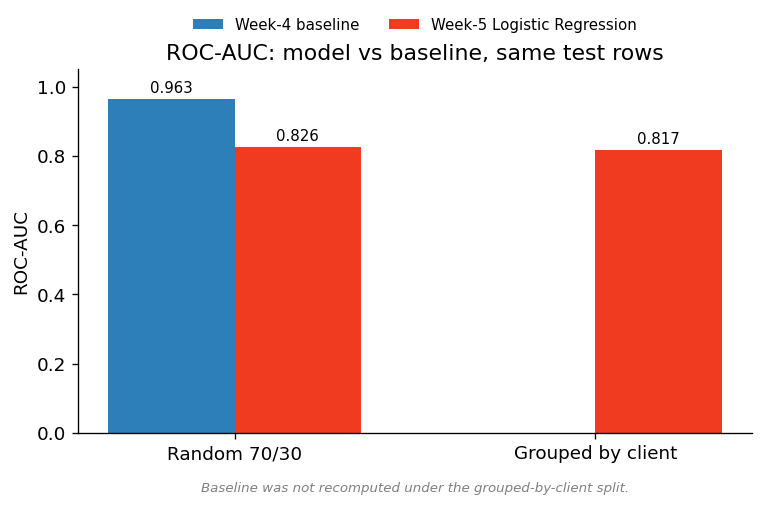

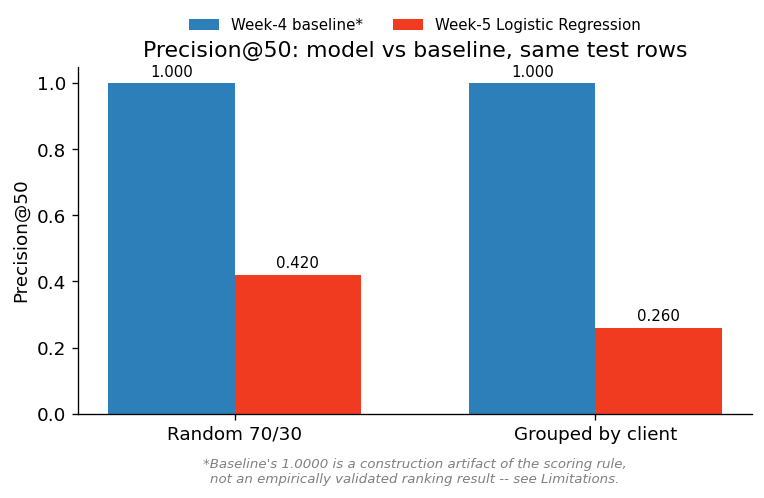

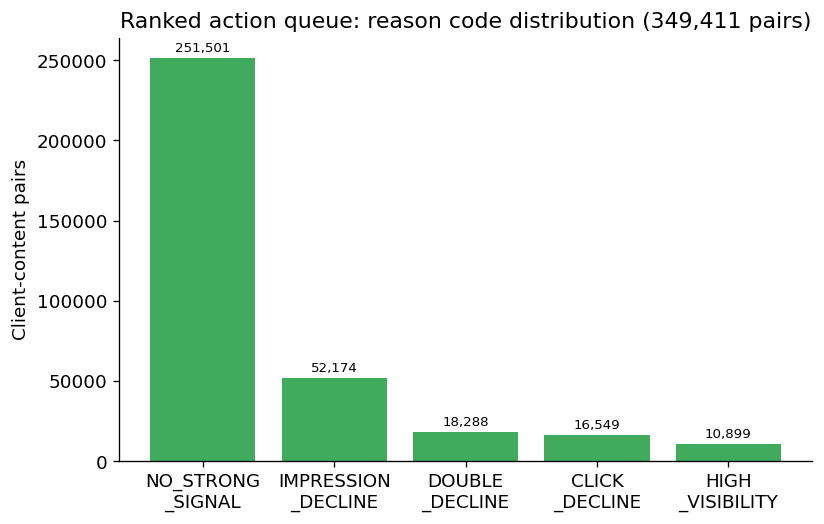

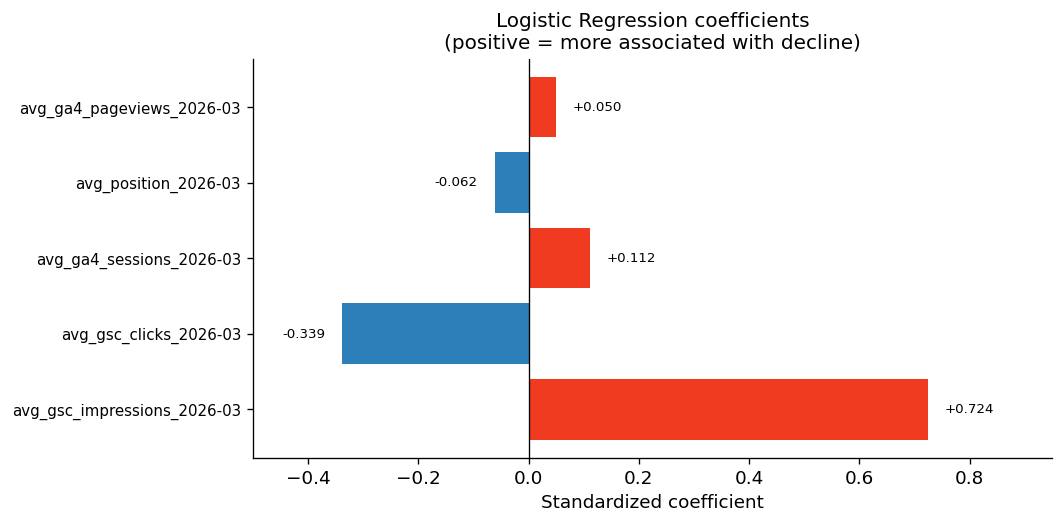

Saved 4 figures to ../figures


In [7]:
import matplotlib.pyplot as plt
import numpy as np
import os

FIG_DIR = "../figures"
os.makedirs(FIG_DIR, exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 120,
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

splits = ["Random 70/30", "Grouped by client"]
x = np.arange(len(splits))
width = 0.35

# ---- Chart 1: ROC-AUC, model vs baseline, both splits ----
# Source: w05_model.ipynb (random split), w06_validation_audit.ipynb (grouped split).
model_auc = [0.8259, 0.8174]
baseline_auc_random = 0.9629

fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.bar(x[0] - width/2, baseline_auc_random, width, label="Week-4 baseline", color="#2c7fb8")
ax.bar(x + width/2, model_auc, width, label="Week-5 Logistic Regression", color="#f03b20")
ax.set_xticks(x); ax.set_xticklabels(splits)
ax.set_ylabel("ROC-AUC"); ax.set_ylim(0, 1.05)
ax.set_title("ROC-AUC: model vs baseline, same test rows")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, 1.18), ncol=2, frameon=False, fontsize=9)
ax.text(x[0] - width/2, baseline_auc_random + 0.02, f"{baseline_auc_random:.3f}", ha="center", fontsize=9)
for xi, val in zip(x, model_auc):
    ax.text(xi + width/2, val + 0.02, f"{val:.3f}", ha="center", fontsize=9)
ax.text(0.5, -0.16, "Baseline was not recomputed under the grouped-by-client split.",
        ha="center", fontsize=8, style="italic", color="gray", transform=ax.transAxes)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/roc_auc_comparison.png")
plt.show()

# ---- Chart 2: Precision@50, model vs baseline, both splits ----
# Source: this week's Precision@50 addendum (run in w05/w06 Colab sessions).
model_p50 = [0.4200, 0.2600]
baseline_p50 = [1.0000, 1.0000]

fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.bar(x - width/2, baseline_p50, width, label="Week-4 baseline*", color="#2c7fb8")
ax.bar(x + width/2, model_p50, width, label="Week-5 Logistic Regression", color="#f03b20")
ax.set_xticks(x); ax.set_xticklabels(splits)
ax.set_ylabel("Precision@50"); ax.set_ylim(0, 1.05)
ax.set_title("Precision@50: model vs baseline, same test rows")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, 1.18), ncol=2, frameon=False, fontsize=9)
for xi, val in zip(x, baseline_p50):
    ax.text(xi - width/2, val + 0.02, f"{val:.3f}", ha="center", fontsize=9)
for xi, val in zip(x, model_p50):
    ax.text(xi + width/2, val + 0.02, f"{val:.3f}", ha="center", fontsize=9)
ax.text(0.5, -0.20, "*Baseline's 1.0000 is a construction artifact of the scoring rule,\nnot an empirically validated ranking result -- see Limitations.",
        ha="center", fontsize=8, style="italic", color="gray", transform=ax.transAxes)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/precision_at_50_comparison.png")
plt.show()

# ---- Chart 3: Reason code distribution from the ranked action queue ----
# Source: w07_action_playbook.ipynb, cell 32.
reason_codes = ["NO_STRONG\n_SIGNAL", "IMPRESSION\n_DECLINE", "DOUBLE\n_DECLINE", "CLICK\n_DECLINE", "HIGH\n_VISIBILITY"]
reason_counts = [251_501, 52_174, 18_288, 16_549, 10_899]

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(reason_codes, reason_counts, color="#41ab5d")
ax.set_ylabel("Client-content pairs")
ax.set_title("Ranked action queue: reason code distribution (349,411 pairs)")
for i, v in enumerate(reason_counts):
    ax.text(i, v + 4000, f"{v:,}", ha="center", fontsize=8)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/reason_code_distribution.png")
plt.show()

# ---- Chart 4: Logistic Regression feature coefficients ----
# Source: w05_model.ipynb, cell 22.
features = ["avg_gsc_impressions_2026-03", "avg_gsc_clicks_2026-03", "avg_ga4_sessions_2026-03",
            "avg_position_2026-03", "avg_ga4_pageviews_2026-03"]
coefficients = [0.723970, -0.338650, 0.111571, -0.061653, 0.049733]
colors = ["#f03b20" if c > 0 else "#2c7fb8" for c in coefficients]

fig, ax = plt.subplots(figsize=(9, 4.5))
y_pos = np.arange(len(features))
ax.barh(y_pos, coefficients, color=colors)
ax.set_yticks(y_pos); ax.set_yticklabels(features, fontsize=9)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlim(-0.5, 0.95)
ax.set_xlabel("Standardized coefficient")
ax.set_title("Logistic Regression coefficients\n(positive = more associated with decline)", fontsize=12)
for yi, val in zip(y_pos, coefficients):
    offset = 0.03 if val >= 0 else -0.03
    ax.text(val + offset, yi, f"{val:+.3f}", va="center",
            ha="left" if val >= 0 else "right", fontsize=8)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/feature_coefficients.png")
plt.show()

print("Saved 4 figures to", FIG_DIR)

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.